In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/refs/heads/master/data/Telco-Customer-Churn.csv"
df=pd.read_csv(url)

In [8]:
pd.set_option("display.max_columns",None) #load all columns as is

In [9]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df['gender'].value_counts()

,count
gender,
Male,3555
Female,3488


In [12]:
male = (df['gender']=='Male').sum()
male

np.int64(3555)

In [13]:
df['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2421
No,1526


In [14]:
internet_servie_DSL = (df['InternetService']=='DSL').sum()
internet_servie_DSL

np.int64(2421)

In [15]:
df['SeniorCitizen'].value_counts()

,count
SeniorCitizen,
0,5901
1,1142


In [16]:
df['PaymentMethod'].value_counts()

,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


In [17]:
new_customer =df[ ((df['gender']=='Female') & (df['SeniorCitizen']==1) & (df['PaymentMethod']=='Mailed check'))]
new_customer.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
139,0390-DCFDQ,Female,1,Yes,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.45,70.45,Yes
176,2656-FMOKZ,Female,1,No,No,15,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.45,1145.7,Yes


In [18]:
new_customer.shape

(50, 21)

In [19]:
df['Churn'] = df['Churn'].map({'No':0,'Yes':1})
df['gender'] = df['gender'].map({'Female':0,'Male':1})
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [20]:
new_customer = df[(df['tenure']<10)|(df['TotalCharges']<500)]
new_customer.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
2,3668-QPYBK,1,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [21]:
new_customer.shape

(2233, 21)

In [22]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [23]:
df.dropna(inplace=True)

In [24]:
df.isnull().sum().sum()

np.int64(0)

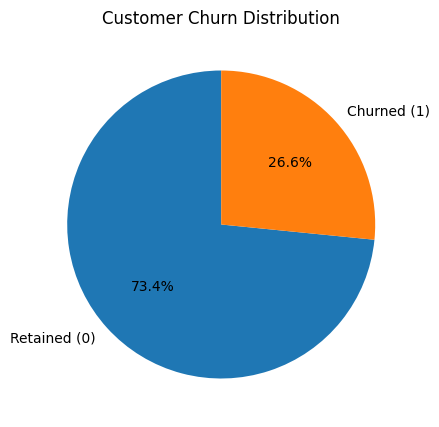

In [25]:
#Pie chart
churn_counts = df['Churn'].value_counts()
labels = ['Retained (0)','Churned (1)']
plt.figure(figsize=(5,5))
plt.pie(churn_counts,labels=labels,autopct='%1.1f%%',startangle=90)
plt.title('Customer Churn Distribution')
plt.show()

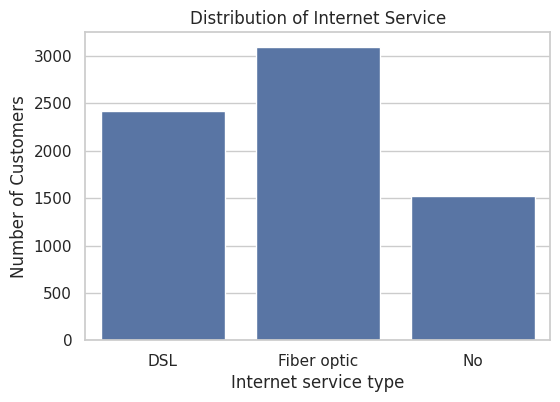

In [26]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='InternetService')
plt.title('Distribution of Internet Service')
plt.xlabel('Internet service type')
plt.ylabel('Number of Customers')
plt.show()

In [40]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

In [28]:
X = df[['tenure']]
y=df['Churn']
X

,tenure
0,1
1,34
2,2
3,45
4,2
...,...
7038,24
7039,72
7040,11
7041,4


In [29]:
y.value_counts() #class imbalance

,count
Churn,
0,5163
1,1869


In [30]:
X_trian, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=42,stratify=y)

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_trian)
X_test_scaled = scaler.transform(X_test)

In [32]:
def model_1():
  model = models.Sequential([
      layers.Dense(12,activation='relu',input_shape=(1,)),
      layers.Dense(8,activation='relu'),
      layers.Dense(1,activation='sigmoid')
  ])
  return model

In [33]:
model_1 = model_1()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model_1.compile(
     optimizer='adam',
     loss='binary_crossentropy',
     metrics=['accuracy'])

In [35]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = model_1.fit(
    X_train_scaled, y_train,
    epochs = 150,
    batch_size = 32,
    validation_split = 0.20
)

Epoch 1/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7327 - loss: 0.5760 - val_accuracy: 0.7404 - val_loss: 0.5273
Epoch 2/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7327 - loss: 0.5178 - val_accuracy: 0.7404 - val_loss: 0.5214
Epoch 3/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7327 - loss: 0.5133 - val_accuracy: 0.7404 - val_loss: 0.5188
Epoch 4/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7444 - loss: 0.5113 - val_accuracy: 0.7502 - val_loss: 0.5188
Epoch 5/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7460 - loss: 0.5101 - val_accuracy: 0.7404 - val_loss: 0.5172
Epoch 6/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7478 - loss: 0.5094 - val_accuracy: 0.7458 - val_loss: 0.5201
Epoch 7/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7556 - loss: 0.5088 - val_accuracy: 0.7502 - val_loss: 0.5169
Epoch 8/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7527 - loss: 0.5086 - val_acc

In [38]:
y_pred_probs = model_1.predict(X_test_scaled)
y_pred = (y_pred_probs>=0.5).astype(int)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [41]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[916, 117],
       [225, 149]])

In [42]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84      1033
           1       0.56      0.40      0.47       374

    accuracy                           0.76      1407
   macro avg       0.68      0.64      0.65      1407
weighted avg       0.74      0.76      0.74      1407



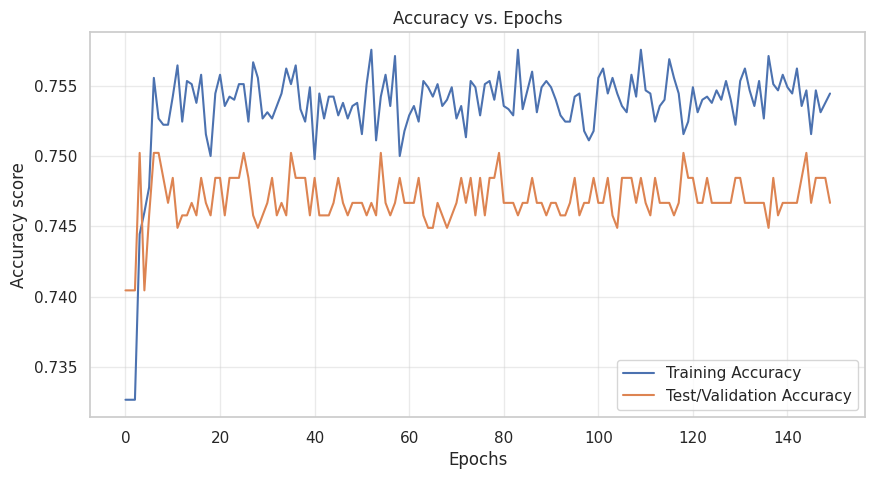

In [53]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Test/Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy score')
plt.title('Accuracy vs. Epochs')
plt.grid(alpha=0.4)
plt.show()

In [55]:
def model_2():
  model = models.Sequential([
      layers.Dense(12,activation='relu',input_shape=(1,)),
      layers.Dropout(0.3),
      layers.Dense(8,activation='relu'),
      layers.Dropout(0.2),
      layers.Dense(1,activation='sigmoid')
  ])
  return model

In [56]:
model_2 = model_2()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [58]:
model_2.compile(
    optimizer='Adam',
    loss='binary_crossentropy',
    metrics = ['accuracy']
)

In [60]:
history = model_2.fit(
    X_train_scaled,y_train,
    batch_size = 32,
    epochs = 150,
    validation_split = 0.20
)

Epoch 1/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.7242 - loss: 0.6109 - val_accuracy: 0.7404 - val_loss: 0.5535
Epoch 2/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7329 - loss: 0.5466 - val_accuracy: 0.7404 - val_loss: 0.5254
Epoch 3/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7329 - loss: 0.5391 - val_accuracy: 0.7404 - val_loss: 0.5219
Epoch 4/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7336 - loss: 0.5292 - val_accuracy: 0.7404 - val_loss: 0.5197
Epoch 5/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7349 - loss: 0.5262 - val_accuracy: 0.7404 - val_loss: 0.5182
Epoch 6/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7400 - loss: 0.5221 - val_accuracy: 0.7404 - val_loss: 0.5177
Epoch 7/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7398 - loss: 0.5265 - val_accuracy: 0.7404 - val_loss: 0.5175
Epoch 8/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7407 - loss: 0.5223 - val_acc

In [61]:
y_pred2_probs = model_2.predict(X_test_scaled)
y_pred2 = (y_pred2_probs>=0.5).astype(int)

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [63]:
cm2 = confusion_matrix(y_test,y_pred2)
cm2

array([[934,  99],
       [245, 129]])

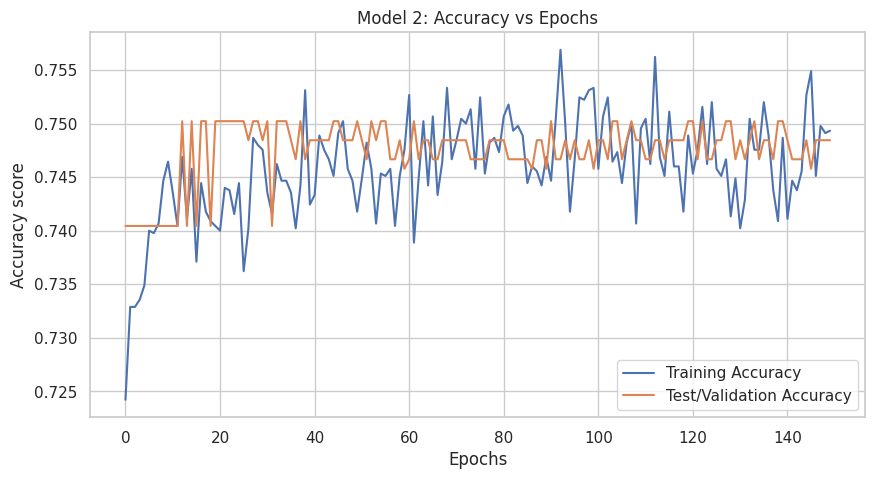

In [73]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Test/Validation Accuracy')
plt.legend(loc='lower right')
plt.xlabel('Epochs')
plt.ylabel('Accuracy score')
plt.title('Model 2: Accuracy vs Epochs')
plt.grid(True)
plt.show()

In [74]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [78]:
X = df[['tenure','MonthlyCharges','TotalCharges']]
X.head()
y = df['Churn']
y.head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [83]:
X.shape

(7032, 3)

In [79]:
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.20,random_state =42, stratify =y)

In [81]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # to prevent data leakage

In [82]:
def model_3():
  model = models.Sequential([
      layers.Dense(12,activation='relu',input_shape=(3,)),
      layers.Dense(8,activation='relu'),
      layers.Dense(1,activation='sigmoid')
  ])
  return model

In [84]:
model_3 = model_3()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [85]:
model_3.compile(
    optimizer = 'Adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [86]:
history = model_3.fit(
    X_train_scaled,y_train,
    epochs = 150,
    batch_size = 32,
    validation_split = 0.2
)

Epoch 1/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.7327 - loss: 0.5706 - val_accuracy: 0.7404 - val_loss: 0.5236
Epoch 2/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7327 - loss: 0.5050 - val_accuracy: 0.7404 - val_loss: 0.4880
Epoch 3/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7522 - loss: 0.4805 - val_accuracy: 0.7911 - val_loss: 0.4698
Epoch 4/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7860 - loss: 0.4662 - val_accuracy: 0.7884 - val_loss: 0.4631
Epoch 5/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7882 - loss: 0.4599 - val_accuracy: 0.7822 - val_loss: 0.4590
Epoch 6/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7860 - loss: 0.4567 - val_accuracy: 0.7822 - val_loss: 0.4580
Epoch 7/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7882 - loss: 0.4551 - val_accuracy: 0.7858 - val_loss: 0.4560
Epoch 8/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7871 - loss: 0.4540 - val_a

In [87]:
y_pred = (model_3.predict(X_test_scaled)>=0.5).astype(int)

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [88]:
cm3 = confusion_matrix(y_test,y_pred)
cm3

array([[913, 120],
       [202, 172]])

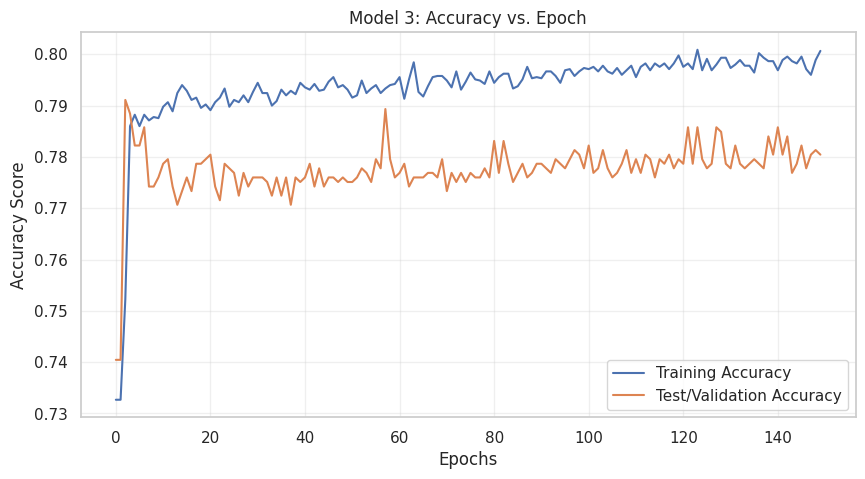

In [92]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Test/Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy Score')
plt.title('Model 3: Accuracy vs. Epoch')
plt.grid(alpha=0.3)
plt.show()